In [1]:
import ssl_fix

In [2]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama
from dotenv import load_dotenv
from langchain.tools import tool
import requests

In [3]:
load_dotenv()

True

In [4]:
import os



In [5]:
llm=ChatGroq(model="llama-3.1-8b-instant",
             api_key=os.getenv("GROQ_API_KEY")
             ) 

In [6]:
@tool 
def get_weather(city:str) -> str:
    """
    Get the current weather for a given city.
    """
    # For demonstration purposes, we'll return a mock response.
    # In a real implementation, you would call a weather API here.
    return f"The current weather in {city} is sunny with a temperature of 25°C."

In [7]:
@tool
def get_weather_data(city: str) -> str:
  """
  This function fetches the current weather data for a given city
  """
  url = f'https://api.weatherstack.com/current?access_key=48c3b2eac48c3c8871c78a5b7ff8326d&query={city}'
 
  response = requests.get(url)
 
  return response.json()

In [8]:
@tool
def get_stock_price(ticket:str) -> str:
    """
    Get the current stock price for a given stock ticker.
    """
    # For demonstration purposes, we'll return a mock response.
    # In a real implementation, you would call a stock price API here.
    return f"The current stock price for {ticket} is $150.00."

In [9]:
@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    r = requests.get(url)
    return r.json()

In [10]:
my_agent= create_agent(
    model=llm,
    tools=[get_weather , get_stock_price],
    system_prompt="You are a helpful assistant that can provide weather information for cities. Use the get_weather tool to fetch the current weather.",
)

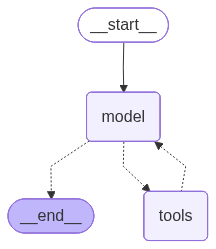

In [11]:
my_agent

In [12]:
response= my_agent.invoke({"messages": "Hello can you tell me current weather in Pune city"})

In [13]:
response

{'messages': [HumanMessage(content='Hello can you tell me current weather in Pune city', additional_kwargs={}, response_metadata={}, id='df031b13-2da0-48ab-9cb9-430267164b48'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'f6na6ddwb', 'function': {'arguments': '{"city":"Pune"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 356, 'total_tokens': 371, 'completion_time': 0.014620769, 'completion_tokens_details': None, 'prompt_time': 0.023818148, 'prompt_tokens_details': None, 'queue_time': 0.055653551, 'total_time': 0.038438917}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f6a13-a256-7c42-94d8-f55999801ddb-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Pune'}, 'id': 'f6na6ddwb', 'type': 'tool_call'}], invalid_tool_calls=[], usage_m

In [15]:
response = my_agent.invoke({"messages": "what is stock price of AAPL?"})
print(response)

{'messages': [HumanMessage(content='what is stock price of AAPL?', additional_kwargs={}, response_metadata={}, id='6ac220ef-7cb5-47ba-9818-6db4e25681f9'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '0x7gp82r5', 'function': {'arguments': '{"symbol":"AAPL"}', 'name': 'get_stock_price'}, 'type': 'function'}, {'id': 'rj38h4d4r', 'function': {'arguments': '{"symbol":"AAPL"}', 'name': 'get_stock_price'}, 'type': 'function'}, {'id': 'rk1r4s0nc', 'function': {'arguments': '{"symbol":"AAPL"}', 'name': 'get_stock_price'}, 'type': 'function'}, {'id': '49ecgvrdg', 'function': {'arguments': '{"symbol":"AAPL"}', 'name': 'get_stock_price'}, 'type': 'function'}, {'id': 'khk3bd1hk', 'function': {'arguments': '{"symbol":"AAPL"}', 'name': 'get_stock_price'}, 'type': 'function'}, {'id': 'abt54fvga', 'function': {'arguments': '{"symbol":"AAPL"}', 'name': 'get_stock_price'}, 'type': 'function'}, {'id': '9d70y13c6', 'function': {'arguments': '{"symbol":"AAPL"}', 'name': 'get_stock_price'}

In [16]:
response['messages'][-1].content

'The current stock price of AAPL is $327.50.'